Phase 1: Environment & Data Preprocessing

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import shap
from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer
from imblearn.over_sampling import SMOTE
from lightgbm import LGBMClassifier
from sklearn.metrics import classification_report

# 1. Load Dataset (AI4I-PMDI 2024 Edition)
df = pd.read_csv('AI4I-PMDI.csv')
df.columns = df.columns.str.strip()

# 2. Basic Data Validation
print("Dataset shape:", df.shape)
print("\nMissing values:\n", df.isnull().sum())
print("\nData types:\n", df.dtypes)

# 3. Feature Engineering
# Map product quality type to numeric
type_mapping = {'L': 0, 'M': 1, 'H': 2}
df['Type'] = df['Type'].map(type_mapping)
if df['Type'].isnull().any():
    print("Warning: Found unknown Type values")

# Physics-based features: Thermal Stress and Power Index
df['Temp_Diff'] = df['Process temperature (K)'] - df['Air temperature (K)']
df['Power'] = df['Torque (Nm)'] * df['Rotational speed (rpm)']

# 4. Data Cleaning
# Drop non-predictive IDs and administrative columns
drop_cols = ['UDI', 'Date', 'System', 'Control', 'Product ID']
df_model = df.drop(drop_cols, axis=1)

# Separate Features and Target
X = df_model.drop('Diagnostic', axis=1)
y = df_model['Diagnostic']

print("\nClass distribution:\n", y.value_counts())

# Train-Test Split (Stratified to maintain failure distribution)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

Dataset shape: (10000, 12)

Missing values:
 UDI                           0
Date                          0
System                        0
Control                       0
Product ID                    0
Type                          0
Air temperature (K)        6563
Process temperature (K)    6563
Rotational speed (rpm)     3321
Torque (Nm)                3437
Tool wear (min)            6679
Diagnostic                    0
dtype: int64

Data types:
 UDI                          int64
Date                           str
System                       int64
Control                        str
Product ID                     str
Type                           str
Air temperature (K)        float64
Process temperature (K)    float64
Rotational speed (rpm)     float64
Torque (Nm)                float64
Tool wear (min)            float64
Diagnostic                     str
dtype: object

Class distribution:
 Diagnostic
No failure                  9652
Heat Dissipation Failure     106
Overstrain 

Phase 2: Imbalanced Data Handling & Training

In [2]:
# 1. Handling Missing Values (Median imputation for robustness)
imputer = SimpleImputer(strategy='median')
X_train_imputed = imputer.fit_transform(X_train)
X_test_imputed = imputer.transform(X_test)

# 2. Address Class Imbalance via SMOTE
# Failures are rare (~3%), SMOTE helps model learn failure patterns
sm = SMOTE(random_state=42)
X_train_res, y_train_res = sm.fit_resample(X_train_imputed, y_train)

print("Original training set shape:", X_train_imputed.shape)
print("Resampled training set shape:", X_train_res.shape)
print("Resampled class distribution:\n", pd.Series(y_train_res).value_counts())

# 3. Model Training: LightGBM Classifier
lgb_model = LGBMClassifier(
    n_estimators=1000,
    learning_rate=0.05,
    random_state=42,
    importance_type='gain',
    verbose=-1
)
lgb_model.fit(X_train_res, y_train_res)

# 4. Evaluation
y_pred = lgb_model.predict(X_test_imputed)
y_prob = lgb_model.predict_proba(X_test_imputed)

print("\n=== Performance Report ===")
print(classification_report(y_test, y_pred))

Original training set shape: (8000, 8)
Resampled training set shape: (46332, 8)
Resampled class distribution:
 Diagnostic
No failure                  7722
Heat Dissipation Failure    7722
Overstrain Failure          7722
Tool Wear Failure           7722
Power Failure               7722
Random Failures             7722
Name: count, dtype: int64


/Users/wenpin/Visual Studio Code/ML_Projects/Jobs/My_PDMI_Project/.venv/lib/python3.14/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/Users/wenpin/Visual Studio Code/ML_Projects/Jobs/My_PDMI_Project/.venv/lib/python3.14/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(



=== Performance Report ===
                          precision    recall  f1-score   support

Heat Dissipation Failure       1.00      1.00      1.00        21
              No failure       1.00      0.98      0.99      1930
      Overstrain Failure       0.95      1.00      0.98        20
           Power Failure       1.00      1.00      1.00        17
         Random Failures       0.00      0.00      0.00         4
       Tool Wear Failure       0.28      0.62      0.38         8

                accuracy                           0.98      2000
               macro avg       0.70      0.77      0.72      2000
            weighted avg       0.99      0.98      0.98      2000



Phase 3: Explainable AI (SHAP Analysis)

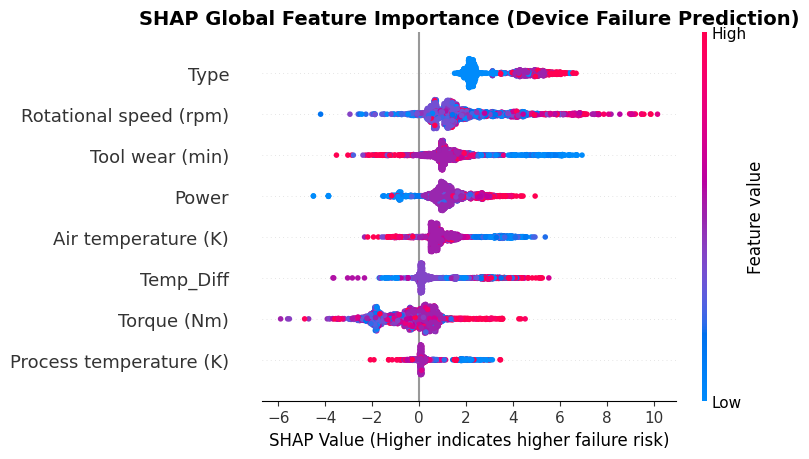

Success: Visualizing Case Index: 218
Actual Diagnosis: Random Failures


<Figure size 2500x300 with 0 Axes>

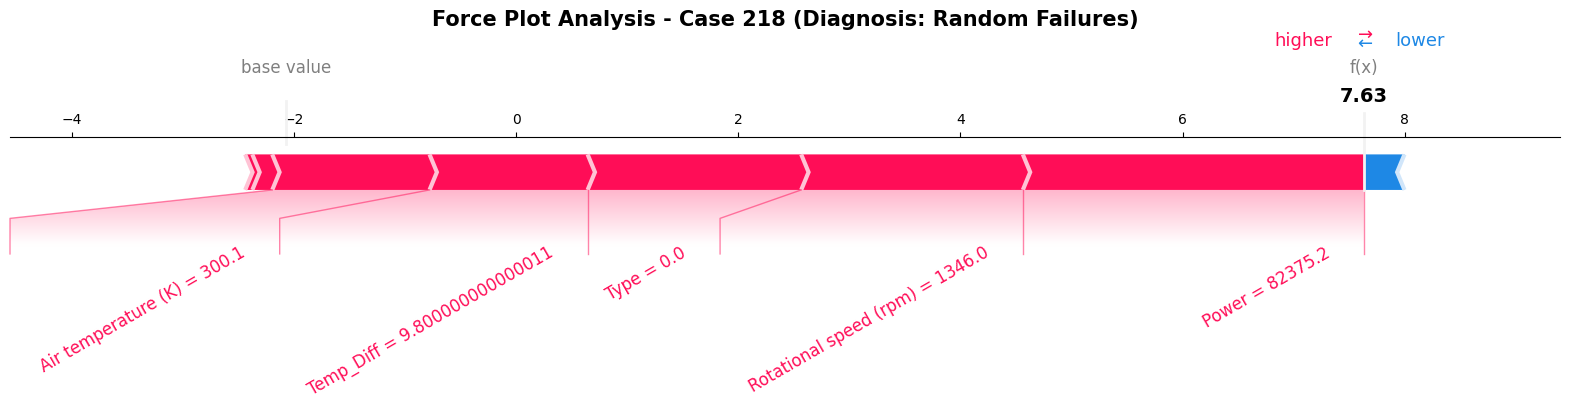

In [4]:
# =============================================================================
# MODEL INTERPRETATION USING SHAP
# This section provides transparency into how the model makes decisions
# =============================================================================

# 1. Initialize SHAP Explainer
# Convert imputed data back to DataFrame to preserve feature names
X_test_df = pd.DataFrame(X_test_imputed, columns=X.columns)
explainer = shap.TreeExplainer(lgb_model)
shap_values = explainer.shap_values(X_test_df)

# 2. Global Interpretation: Summary Plot for Multi-class
# Shows top features driving model predictions globally
# Focus on failure class to identify equipment failure root causes

plt.figure(figsize=(12, 8))

# Select correct class index for multi-class SHAP values
if isinstance(shap_values, list):
    target_shap_values = shap_values[1]
elif len(shap_values.shape) == 3:
    target_shap_values = shap_values[:, :, 1]
else:
    target_shap_values = shap_values

shap.summary_plot(target_shap_values, X_test_df, show=False, max_display=15)
plt.title("SHAP Global Feature Importance (Device Failure Prediction)", fontsize=14, fontweight='bold')
plt.xlabel("SHAP Value (Higher indicates higher failure risk)", fontsize=12)
plt.tight_layout()
plt.savefig('Impact of Key Variables on Equipment Failure Risk.png', dpi=300, bbox_inches='tight')
plt.show()

# 3. Local Interpretation: Force Plot for Specific Failure Case
# Analyze why model predicted a specific equipment breakdown

shap.initjs()

# Find the failure class (class with fewest samples)
unique_classes, class_counts = np.unique(y_test.values, return_counts=True)
failure_class = unique_classes[np.argmin(class_counts)]
fail_indices = np.where(y_test.values == failure_class)[0]

if len(fail_indices) > 0:
    target_idx = fail_indices[0]
    actual_diagnosis = y_test.values[target_idx]
    
    print(f"Success: Visualizing Case Index: {target_idx}")
    print(f"Actual Diagnosis: {actual_diagnosis}")
    
    # Extract values for specific sample and failure class
    if isinstance(shap_values, list):
        sv = shap_values[1][target_idx]
        ev = explainer.expected_value[1] if isinstance(explainer.expected_value, (list, np.ndarray)) else explainer.expected_value
    else:
        sv = target_shap_values[target_idx]
        ev = explainer.expected_value[1] if isinstance(explainer.expected_value, (list, np.ndarray)) else explainer.expected_value

    # Generate force plot with readability optimization
    plt.figure(figsize=(25, 3))
    shap.force_plot(
        ev,
        sv,
        X_test_df.iloc[target_idx, :],
        matplotlib=True,
        show=False,
        contribution_threshold=0.15,
        text_rotation=30
    )
    
    plt.title(f"Force Plot Analysis - Case {target_idx} (Diagnosis: {actual_diagnosis})",
              pad=80, fontsize=15, fontweight='bold')
    plt.savefig('Root Cause Diagnostics for a Specific Failure Event.png', dpi=300, bbox_inches='tight')
    plt.show()

else:
    print("Warning: No failure samples found in test set.")